---
format: 
    html:
        page-layout: full
        embed-resources: True
        grid:
            body-width: 1200px
        fontsize: 18px
        code-fold: true
        code-summary: "Show the code"
        code-tools: true
        code-copy: false
        number-sections: true

title: A Quantitative Approach to Tactical Asset Allocation - Case Study
author: Rui Carvalho Caseiro
date: last-modified

warning: False
toc: True
---

In [1]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format
import numpy as np
import yfinance as yf
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

import warnings
warnings.filterwarnings("ignore")

import MyCustomLibrary.main as main
import MyCustomLibrary.backtester as bt
import MyCustomLibrary.backtester_tools as tools
import MyCustomLibrary.features as my_ta

## Study overview

The intent of this study is to analyze out-of-sample performance of the TAA model published on the paper "A Quantitative Approach to Tactical Asset Allocation" by Mebane Faber, author named the model as “Global Tactical Asset Allocation” or “GTAA”, it's been published back in 2007 and reviewed in 2013.

Author presents the GTAA model as a portfolio alternative to the traditional 60/40 portfolio, aiming to deliver higher absolute and risk adjusted returns.

Author warning about a possible limitation ot the model:
"a trend-following model can underperform buy and hold during a roaring bull market similar to the U.S. equity markets in the 1990s.  On the flip side, the timing model can avoid lengthy and protracted bear markets.  Consequently, the value added by timing is evident only over the course of entire business cycles."

The timing model also uses equal weightings and treats each asset class independently – it is either long the asset class or in cash with its 20% allocation of the funds [Faber (2013)](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=962461).

### So this study aims to answer to this question: **Does GTAA retain its risk-adjusted edge post-2013?**

#### GTAA consists of five global asset classes:
- US stocks (S&P 500)
- Foreign stocks (MSCI EAFE)
- US 10 year Governement Bonds
- Real Estate Investment Trust (NAREIT index)
- Commodities (Goldman Sachs Commodity Index)

#### Timing Signals generation:
- **BUY RULE:** Buy when monthly price > n month SMA. 
- **SELL RULE:** Sell and move to cash when monthly price < n month SMA

#### Some backtest considerations
1.  All entry and exit prices are on the next month open to avoid look ahead bias.
2.  All data series are total return series including dividends, updated monthly. 
3.  A 0.15% commission is added to turn backtested TAA more realistic.

## Data

### Obtain data from Yahoo Finance API

Since initial study In sample testing period is comprised from (1973-2012), this study Out of Sample analysis period will be from 2013-01-01 until 2026-01-01, totalling 13 years or 156 months. In order to obtain the 10 month SMA, there's a need to obtain data 10 months prior to the start analysis period, monthly data is extracted from Yahoo Finance API, since 2012-01-01.

In [2]:
#| code-fold: show

# SPY  – SPDR S&P 500 ETF
# EFA  – iShares MSCI EAFE ETF
# IEF  - iShares 7-10 Year Treasury Bond ETF
# IFGL - iShares International Developed Real Estate ETF
# GSG  - iShares S&P GSCI Commodity-Indexed Trust

tickers = ['SPY', 'EFA', 'IEF', 'IFGL', 'GSG']

quotes = yf.download(tickers, interval='1mo',
                     start='2011-12-31', end='2026-01-02',
                     progress=False, auto_adjust=True)
quotes = quotes.swaplevel(axis='columns').sort_index(axis='columns')
quotes.dropna(inplace=True)

quotes

Ticker        EFA                                 GSG                    \
Price       Close   High   Low  Open     Volume Close  High   Low  Open   
Date                                                                      
2012-01-01  34.21  34.76 32.14 33.16  392456200 33.77 34.44 33.18 33.53   
2012-02-01  35.86  36.51 34.64 34.67  386977800 35.87 36.43 33.37 33.95   
2012-03-01  36.02  36.68 34.51 36.06  398944100 34.78 36.72 34.51 35.92   
2012-04-01  35.27  36.53 33.89 35.85  392512500 34.66 35.45 33.80 34.54   
2012-05-01  31.34  35.58 30.98 35.19  487045100 30.23 34.85 29.98 34.41   
...           ...    ...   ...   ...        ...   ...   ...   ...   ...   
2025-09-01  91.71  92.10 88.44 88.50  331534400 22.97 23.46 22.48 22.91   
2025-10-01  92.81  94.24 90.48 92.21  334540600 23.21 23.47 22.37 22.81   
2025-11-01  93.50  94.97 89.59 92.88  305832000 23.27 23.68 22.50 23.29   
2025-12-01  94.32  95.69 92.45 93.23  426240800 23.06 23.77 22.47 23.27   
2026-01-01 100.74 102.32 96.51 97.03  424640600 25.48 26.33 22.93 23.01   

Ticker                ...  IFGL                               SPY         \
Price         Volume  ... Close  High   Low  Open   Volume  Close   High   
Date                  ...                                                  
2012-01-01   4983000  ... 13.96 14.26 12.85 13.14  1643900 102.29 103.91   
2012-02-01   5498800  ... 14.95 15.11 14.14 14.14   992600 106.73 107.64   
2012-03-01   5152300  ... 14.61 15.19 14.36 14.97  1135400 109.68 110.47   
2012-04-01   4226500  ... 14.94 15.07 14.24 14.73  1626300 109.42 111.26   
2012-05-01   5714200  ... 13.63 15.05 13.58 14.95  1035500 102.85 110.83   
...              ...  ...   ...   ...   ...   ...      ...    ...    ...   
2025-09-01  12865100  ... 22.43 23.10 21.92 22.16   624500 660.58 661.73   
2025-10-01  15432100  ... 22.31 23.04 22.15 22.60   417000 678.20 685.80   
2025-11-01  18676700  ... 22.69 22.84 21.85 22.28   134300 679.52 681.92   
2025-12-01  16217200  ... 22.66 23.01 22.16 22.60   335900 678.06 687.74   
2026-01-01  14905100  ... 24.06 24.38 22.82 23.08   267300 690.09 695.94   

Ticker                                
Price         Low   Open      Volume  
Date                                  
2012-01-01  98.48  99.51  2883821400  
2012-02-01 102.92 103.04  2894582000  
2012-03-01 104.66 106.95  3057516200  
2012-04-01 106.21 110.03  3035644100  
2012-05-01 101.35 109.36  4004156100  
...           ...    ...         ...  
2025-09-01 629.58 632.14  1606348500  
2025-10-01 649.14 659.42  1781815100  
2025-11-01 647.17 681.79  1664668300  
2025-12-01 667.40 674.97  1656188700  
2026-01-01 674.73 683.84  1600537800  

[169 rows x 25 columns]

In [3]:
quotes.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 169 entries, 2012-01-01 to 2026-01-01
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (EFA, Close)    169 non-null    float64
 1   (EFA, High)     169 non-null    float64
 2   (EFA, Low)      169 non-null    float64
 3   (EFA, Open)     169 non-null    float64
 4   (EFA, Volume)   169 non-null    int64  
 5   (GSG, Close)    169 non-null    float64
 6   (GSG, High)     169 non-null    float64
 7   (GSG, Low)      169 non-null    float64
 8   (GSG, Open)     169 non-null    float64
 9   (GSG, Volume)   169 non-null    int64  
 10  (IEF, Close)    169 non-null    float64
 11  (IEF, High)     169 non-null    float64
 12  (IEF, Low)      169 non-null    float64
 13  (IEF, Open)     169 non-null    float64
 14  (IEF, Volume)   169 non-null    int64  
 15  (IFGL, Close)   169 non-null    float64
 16  (IFGL, High)    169 non-null    float64
 17  (IFGL, Low)     

In [4]:
quotes.isna().sum()

Ticker  Price 
EFA     Close     0
        High      0
        Low       0
        Open      0
        Volume    0
GSG     Close     0
        High      0
        Low       0
        Open      0
        Volume    0
IEF     Close     0
        High      0
        Low       0
        Open      0
        Volume    0
IFGL    Close     0
        High      0
        Low       0
        Open      0
        Volume    0
SPY     Close     0
        High      0
        Low       0
        Open      0
        Volume    0
dtype: int64

All data is complete, Numbers formatting is correct!

### Data prep

This step will add the 3, 6, 9, 10 and 12 month SMAs for the 5 asset classes, and make sure the initial data starts at 2013-01-01.

In [5]:
lookbacks = [3, 6, 9, 10, 12]

def df_add_strategy_factors(quotes_df: pd.DataFrame, lookbacks: list, append_df: bool=True) -> pd.DataFrame:
    ''' 
        Input: Feed a Multi Level DataFrame with several assets prices
        Output: Get the same Data Frame plus Several indicators for each symbol
    '''
    symbols = quotes_df.columns.get_level_values(0).unique()
    result_df = pd.DataFrame()

    for symbol in symbols:
        close_series = quotes_df[(symbol, 'Close')]

        new_columns = {}

        for lookback in lookbacks:
            new_columns[f'SMA{lookback}'] = my_ta.get_SMA(close_series, lookback)

        symbol_df = pd.DataFrame(new_columns)
        symbol_df.columns = pd.MultiIndex.from_product([[symbol], symbol_df.columns])
        result_df = pd.concat([result_df, symbol_df], axis=1)
        
    if append_df:
        result_df = pd.concat([quotes_df, result_df], axis=1).sort_index(axis=1)
        
    return result_df

main.timer.start()
screened_df = df_add_strategy_factors(quotes_df=quotes, lookbacks=lookbacks, append_df=True)
screened_df = screened_df.loc['2013':]
main.timer.stop()

screened_df


[*] Total runtime: 8.07 ms


EFA                                                              \
            Close   High   Low  Open SMA10 SMA12  SMA3  SMA6  SMA9     Volume   
Date                                                                            
2013-01-01  40.03  40.34 38.48 39.15 35.43 35.52 38.40 36.90 35.45  328752800   
2013-02-01  39.52  40.45 38.70 40.29 35.86 35.82 39.24 37.71 36.36  371327400   
2013-03-01  40.03  40.72 39.08 39.23 36.73 36.16 39.86 38.45 37.17  372903700   
2013-04-01  42.04  42.08 39.43 39.76 37.66 36.72 40.53 39.46 38.11  423340200   
2013-05-01  40.77  43.54 40.75 42.08 38.38 37.51 40.95 40.10 38.79  415425700   
...           ...    ...   ...   ...   ...   ...   ...   ...   ...        ...   
2025-09-01  91.71  92.10 88.44 88.50 82.76 81.52 89.17 86.90 83.95  331534400   
2025-10-01  92.81  94.24 90.48 92.21 84.84 82.97 91.46 88.73 85.76  334540600   
2025-11-01  93.50  94.97 89.59 92.88 86.54 84.49 92.67 90.02 87.40  305832000   
2025-12-01  94.32  95.69 92.45 93.23 88.09 86.35 93.54 91.36 89.11  426240800   
2026-01-01 100.74 102.32 96.51 97.03 90.28 88.37 96.19 93.82 91.22  424640600   

            ...    SPY                                                   \
            ...  Close   High    Low   Open  SMA10  SMA12   SMA3   SMA6   
Date        ...                                                           
2013-01-01  ... 119.19 120.18 115.23 115.54 110.72 110.30 114.72 113.35   
2013-02-01  ... 120.71 122.04 118.42 119.95 111.85 111.46 117.50 114.97   
2013-03-01  ... 124.74 124.88 119.76 120.30 114.03 112.72 121.55 116.89   
2013-04-01  ... 127.70 127.73 122.80 125.23 116.16 114.24 124.38 119.55   
2013-05-01  ... 130.72 135.21 126.44 127.42 118.40 116.56 127.72 122.61   
...         ...    ...    ...    ...    ...    ...    ...    ...    ...   
2025-09-01  ... 660.58 661.73 629.58 632.14 597.48 593.78 642.32 611.46   
2025-10-01  ... 678.20 685.80 649.14 659.42 607.73 603.75 659.47 633.12   
2025-11-01  ... 679.52 681.92 647.17 681.79 616.36 611.05 672.77 649.26   
2025-12-01  ... 678.06 687.74 667.40 674.97 625.59 619.57 678.59 660.46   
2026-01-01  ... 690.09 695.94 674.73 683.84 639.46 627.64 682.56 671.01   

                               
             SMA9      Volume  
Date                           
2013-01-01 110.86  2587140200  
2013-02-01 112.85  2581459300  
2013-03-01 114.87  2330972300  
2013-04-01 117.03  2907035000  
2013-05-01 119.22  2781596000  
...           ...         ...  
2025-09-01 599.90  1606348500  
2025-10-01 609.34  1781815100  
2025-11-01 619.77  1664668300  
2025-12-01 633.84  1656188700  
2026-01-01 649.60  1600537800  

[157 rows x 50 columns]

###  Benchmarks generation

#### Naive equally weighted portfolio

A naive equal weighting portfolio is generated in order to serve as benchmark against GTAA. This naive portfolio is consisted of the 5 GTAA asset classes, fully invested for the whole period with equal weights monthly rebalanced.

In [6]:
#| code-fold: show

def generate_ew_portfolio(quotes_df):

    close_prices = quotes_df.swaplevel(axis='columns').loc[:, 'Close']
    rets = close_prices.pct_change()
    rets.iloc[0] = 0

    ew_portfolio = rets.mean(axis=1).add(1).cumprod()
    ew_portfolio.name = 'ew_portfolio'

    return ew_portfolio

ew_portfolio = generate_ew_portfolio(screened_df)
ew_portfolio

Date
2013-01-01   1.00
2013-02-01   0.99
2013-03-01   1.01
2013-04-01   1.03
2013-05-01   1.00
             ... 
2025-09-01   1.79
2025-10-01   1.81
2025-11-01   1.82
2025-12-01   1.82
2026-01-01   1.91
Name: ew_portfolio, Length: 157, dtype: float64

#### Naive Buy & Hold portfolio

A naive buy & hold portfolio is generated in order to serve as benchmark against GTAA. This naive portfolio is consisted of the 5 GTAA asset classes, fully invested for the whole period with initial equal weights.

In [7]:
#| code-fold: show

def generate_buy_hold_portfolio(quotes_df):

    close_prices = quotes_df.swaplevel(axis='columns').loc[:, 'Close'].sort_index(axis=1)

    initial_prices = close_prices.iloc[0]
    n_assets = len(initial_prices)

    # equal capital allocation at t0
    initial_weights = pd.Series(1 / n_assets, index=initial_prices.index)

    # normalize prices to 1 at start, then weight them
    rel_prices = close_prices[initial_prices.index].div(initial_prices)

    buy_hold_portfolio = (rel_prices * initial_weights).sum(axis=1)
    buy_hold_portfolio.name = "buy_hold_portfolio"

    return buy_hold_portfolio

bh_portfolio = generate_buy_hold_portfolio(screened_df)
bh_portfolio

Date
2013-01-01   1.00
2013-02-01   0.99
2013-03-01   1.01
2013-04-01   1.03
2013-05-01   1.00
             ... 
2025-09-01   2.18
2025-10-01   2.22
2025-11-01   2.23
2025-12-01   2.23
2026-01-01   2.31
Name: buy_hold_portfolio, Length: 157, dtype: float64

#### Naive 60-40 portfolio

60% US equities (SPY  – SPDR S&P 500 ETF)
40% Bonds (IEF  - iShares 7-10 Year Treasury Bond ETF)

This portfolio is monthly rebalanced to target exposures.

In [8]:
#| code-fold: show

def generate_6040_portfolio(quotes_df):

    close_prices = quotes_df.swaplevel(axis='columns').loc[:, 'Close'][['SPY', 'IEF']]
    rets = close_prices.pct_change()
    rets.iloc[0] = 0

    portfolio_6040 = (rets['SPY']*0.6 + rets['IEF']*0.4).add(1).cumprod()
    portfolio_6040.name='6040_portfolio'

    return portfolio_6040

portfolio_6040 = generate_6040_portfolio(screened_df)
portfolio_6040

Date
2013-01-01   1.00
2013-02-01   1.01
2013-03-01   1.03
2013-04-01   1.05
2013-05-01   1.06
             ... 
2025-09-01   3.10
2025-10-01   3.16
2025-11-01   3.17
2025-12-01   3.15
2026-01-01   3.19
Name: 6040_portfolio, Length: 157, dtype: float64

## Backtesting

In [9]:
#| include: false

# screened_df = pd.read_csv('screened_df_GTAA.csv', index_col=[0], parse_dates=[0], header=[0,1])
# screened_df

In [10]:
#| include: false

# def vectorized_backtest(quotes_df: pd.DataFrame):

#     df = pd.DataFrame()
    
#     for ticker in quotes_df.columns.get_level_values(0).unique().tolist():
        
#         ticker_returns = quotes_df[(f'{ticker}', 'Close')].pct_change(1)
#         signals = np.where(quotes_df[(f'{ticker}', 'Close')].shift(1) > quotes_df[(f'{ticker}', 'SMA10')].shift(1), 1, 0)

#         df.loc[:, f'{ticker}'] = ticker_returns * signals

#     df['GTAA'] = df.mean(axis=1)
#     df.iloc[0] = 0

#     return df.add(1).cumprod()

# GTAA_bt = vectorized_backtest(screened_df)
# GTAA_bt

### Signals generation

 - **BUY RULE:** Buy when monthly price > n-month SMA. 
 - **SELL RULE:** Sell and move to cash when monthly price < n-month SMA

In [11]:
#| code-fold: show

def symbol_above_SMA(symbol_df: pd.DataFrame, sma_lookback: int, row: int)-> bool:
    """True if last month close is above last month SMA value."""
    
    return bool(symbol_df['Close'].iloc[row] > symbol_df[f'SMA{sma_lookback}'].iloc[row])


def symbol_below_SMA(symbol_df: pd.DataFrame, sma_lookback: int, row: int)-> bool:
    """True if last month close is below last month SMA value."""

    return bool(symbol_df['Close'].iloc[row] < symbol_df[f'SMA{sma_lookback}'].iloc[row])

### Strategy Implementation

In [12]:
def get_rebalance_size(symbol_target_exposure: float,
                        symbol_current_exposure: float,
                        symbol_price: float,
                        equity_value: float,
                        rebalance_threshold: float=0.05
    ):

    rebalancing_delta = symbol_target_exposure - symbol_current_exposure

    if abs(rebalancing_delta) < rebalance_threshold:
        return 0

    rebalancing_size = tools.position_size_Fixed_Fractional(equity_value=equity_value,
                                                        price=symbol_price,
                                                        portfolio_weight=rebalancing_delta)
    
    return rebalancing_size

In [13]:
class GTAAStrategy(bt.Strategy):
    
    def init(self,
             sma_lookback:int,
             **kwargs
             ):
        
        self.sma_lookback = sma_lookback
        self.symbols_list = self.data.columns.get_level_values(0).unique().tolist()

    def next(self, i, record):

        try:
            equity_value = (self.assets_value + self.cash)

            for symbol in self.symbols_list:

                ###------------Rebalancing conditions------------###
                if symbol_above_SMA(self.data[symbol], self.sma_lookback, row=i-1):
                    symbol_price = record[(symbol,'Open')]
                    symbol_target_exposure = 1/len(self.symbols_list)
                    symbol_current_exposure = self.symbol_total_positions_exposure(symbol)

                    rebalance_size = get_rebalance_size(symbol_target_exposure, symbol_current_exposure,
                                                        symbol_price, equity_value, rebalance_threshold=0.05)
                    
                    if rebalance_size == 0:
                        pass
                    
                    elif rebalance_size > 0:
                        # Buy
                        self.open_long(symbol=symbol, price=symbol_price, size=int(rebalance_size))

                    else:
                        # Sell
                        self.close(symbol=symbol, price=symbol_price, size=int(abs(rebalance_size))+1, why_exit='Rebalancing sell order')


                ###------------Sell conditions------------###
                else:
                    self.close(symbol=symbol, price=record[(symbol,'Open')], why_exit='Symbol below MA')

                        
        except Exception as e:
            import traceback
            print(traceback.format_exc())

In [14]:
#| include: false
# Limited testing to see if everything is working as intended.

# lt_backtest = bt.Backtest(GTAAStrategy, screened_df.iloc[:50], cash=100_000, commission=0.00)
# lt_result = lt_backtest.run(sma_lookback=10)

# tools.metrics_returns_and_trades(lt_result.returns, lt_result.trades)

### Optimization Training Data

> It is important that the basic buy-and-sell rules are successful across a range of calculation periods and similar markets. If this fails, then you need to rethink your idea. I don’t believe in adding rules to make the strategy more complex in the hope that one rule will turn a losing idea into a profitable one. It is necessary that the basic concept is robust before moving forward. Then we can try to make it better.
> — Perry Kaufman

- GTAA will be performed with all availabe previosuly defined SMA lookbacks (3, 6, 9, 10, 12) in order to assess parameters sensitivity and avoid overfitting by studying only 1 lookback.
- A commission of 0.15% is added in order to turn this TAA implementation more realistic.
- The out-of-sample period covers 156 months from January 2013 through January 2026.
- There will be monthly rebalancing if the 5% delta threhshold is met. e.g. target exposure is always 20% (1/no. assets), if current exposure of a symbol in any given time gets to 25% or more, it gets trimmed back to 20%.

In [15]:
#| code-fold: show

optimize_lookbacks = bt.Optimization(GTAAStrategy, screened_df, cash=100_000, commission=0.0015)

values = [
    lookbacks
    ]

main.timer.start()
optimize_lookbacks.run(values)
main.timer.stop()

Optimization Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Optimization Progress:  20%|██        | 1/5 [00:00<00:00,  4.80it/s]

Optimization Progress:  40%|████      | 2/5 [00:00<00:00,  4.79it/s]

Optimization Progress:  60%|██████    | 3/5 [00:00<00:00,  4.74it/s]

Optimization Progress:  80%|████████  | 4/5 [00:00<00:00,  4.79it/s]

Optimization Progress: 100%|██████████| 5/5 [00:01<00:00,  4.81it/s]

Optimization Progress: 100%|██████████| 5/5 [00:01<00:00,  4.79it/s]


[*] Total runtime: 1.04 s


#### Returns Analysis

In [16]:
bt_lookbacks = pd.concat([bh_portfolio, ew_portfolio, portfolio_6040, optimize_lookbacks.equity_curves()], axis=1).dropna(axis=0)

main.plot_comparative_graph(bt_lookbacks)

This chart is pretty clear! 60/40 portfolio was the big winner over this whole period, and by a decent margin. Buy and hold also did really well, which tells that this was a market where just staying invested worked better than trying to time it. 

The tactical SMA versions all ended up in the same general area, but the shorter lookbacks seem to struggle more, especially the 3-month one. So the overall conclusion here is that, in this OOS sample, the timing rules gave up a lot of upside.

In [17]:
strats_performance =  pd.concat([tools.strategy_performance_metrics(bt_lookbacks, steps_per_year=12, rf=0), 
                                 optimize_lookbacks.optimization_trades_stats()], 
                                 axis='index').fillna('-')
strats_performance

,buy_hold_portfolio,ew_portfolio,6040_portfolio,3,6,9,10,12
CAGR %,6.66,5.09,9.34,2.60,3.35,3.92,3.64,4.16
Ann. Vola %,11.39,11.05,9.29,6.13,5.98,6.00,6.00,5.81
Max Drawdown %,-21.78,-20.73,-20.53,-12.18,-12.02,-8.24,-8.45,-7.62
VaR 5%,-4.57,-4.30,-4.00,-2.93,-2.91,-2.88,-2.88,-2.88
Time in Market %,100.00,100.00,100.00,100.00,98.08,99.36,99.36,100.00
Sharpe,0.58,0.46,1.00,0.42,0.56,0.65,0.61,0.72
Sortino,0.82,0.59,1.46,0.62,0.79,0.98,0.92,1.07
Calmar,0.31,0.25,0.45,0.21,0.28,0.48,0.43,0.55
Efficiency,0.07,0.05,0.09,0.03,0.03,0.04,0.04,0.04
Nr trades,-,-,-,134.00,82.00,67.00,70.00,63.00


On absolute returns, the naive portfolios win pretty clearly here. 60/40 has the highest CAGR at 9.34%, buy-and-hold comes next at 6.66%, and all the SMA tactical versions lag behind, topping out at 4.16% for the 12-month rule. 

On risk, the tactical models do what they’re supposed to do, with much lower volatility and way smaller maximum drawdowns than the naive portfolios, especially versus buy-and-hold. 

In risk-adjusted terms, the picture is more mixed, 60/40 portfolio still has the best Sharpe at 1.00, but among the SMA variants the 3 longest lookbacks look better than both buy and hold and equally weighted portfolio.

The longer SMA rules trade less, hold positions longer, and have better trade quality overall. As the SMA lookback gets longer, profit factor, reward/risk, and expectancy generally improve, even though the win rate actually drifts a bit lower.

#### Parameters Sensitivity

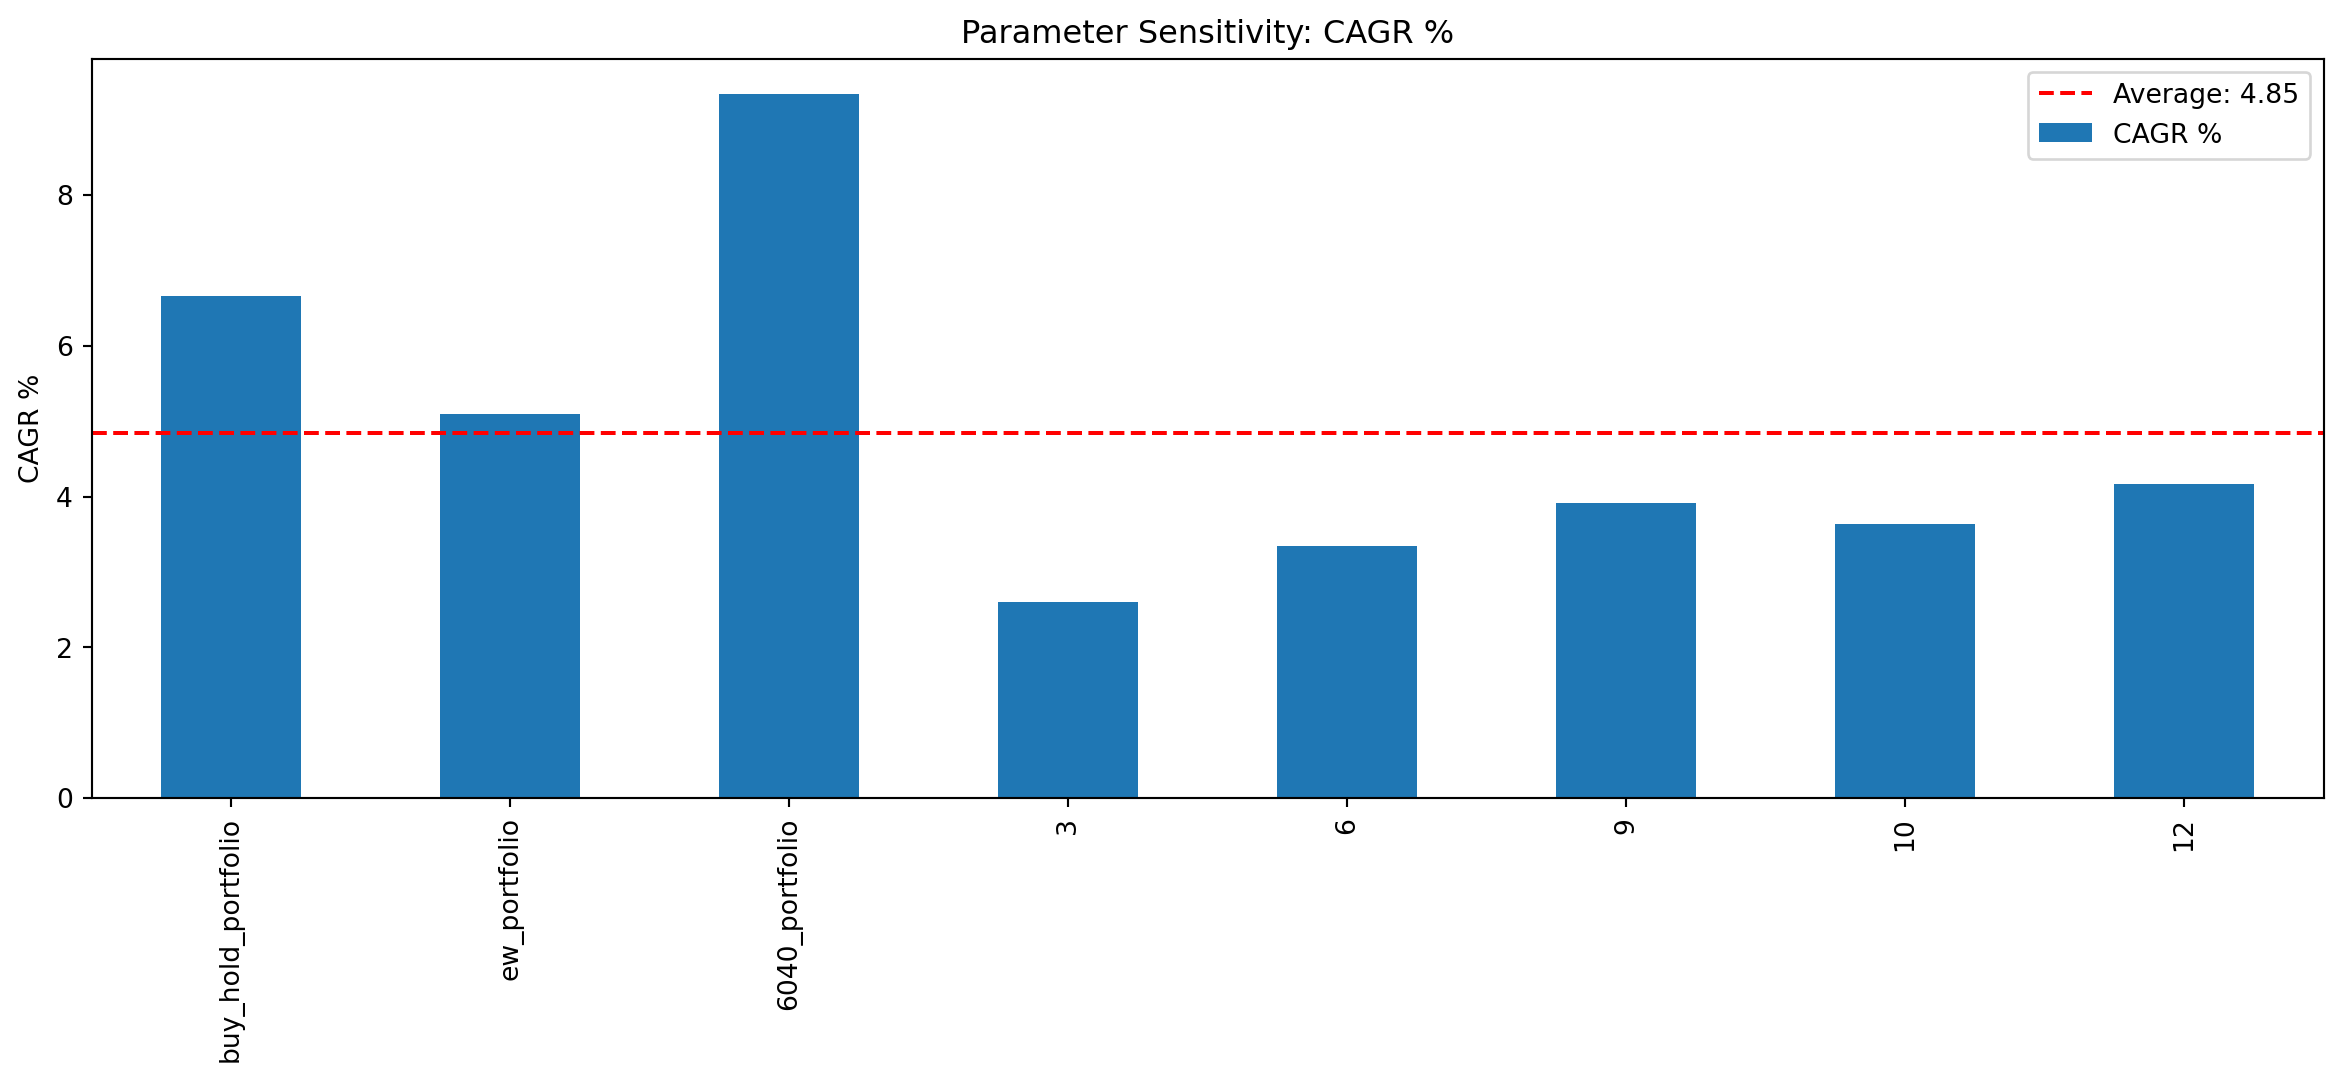

In [18]:
tools.parameter_sensitivity_bar_plot(strats_performance, 'CAGR %')

No single SMA tactical stretgy is able to beat naive portfolios in absolute returns terms. Inside tactical strategies the longer lookbacks have delivered higher annualized returns.

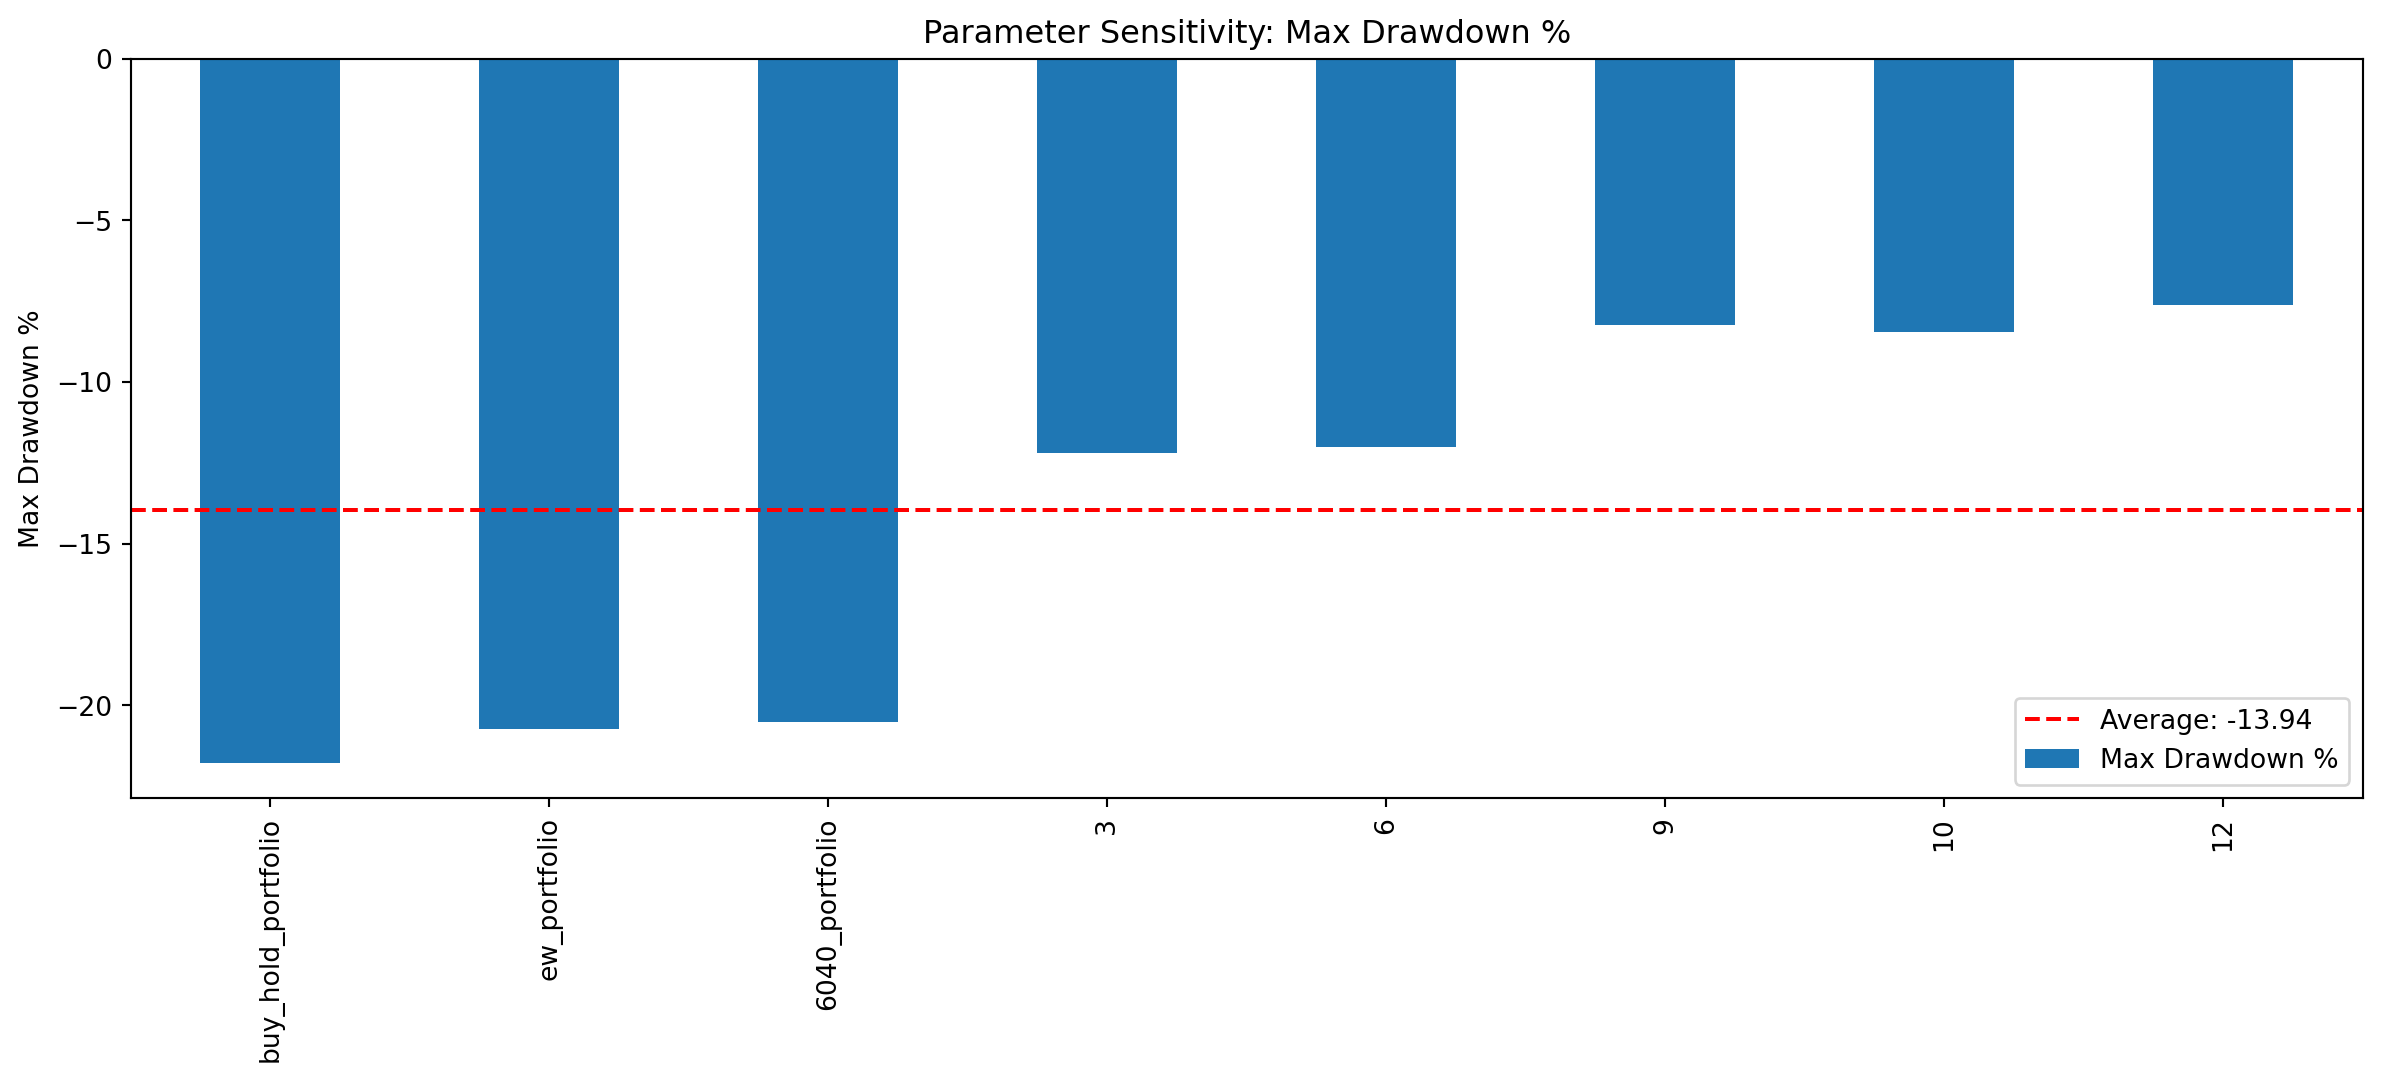

In [19]:
tools.parameter_sensitivity_bar_plot(strats_performance, 'Max Drawdown %')

All SMA tactical rules have beaten naive portfolios in terms of downside risk as measured by Maximum drawdown, with the longer lookbacks showing the best downside protection.

#### Profit probability analysis

In [20]:
tools.metrics_time_window_analysis(bt_lookbacks, lookbacks=[6, 12, 24, 48, 60])

,buy_hold_portfolio,ew_portfolio,6040_portfolio,3,6,9,10,12
6-month,74.8%,70.2%,86.1%,58.9%,64.9%,66.2%,61.6%,65.6%
12-month,73.1%,69.7%,90.3%,60.7%,68.3%,70.3%,67.6%,72.4%
24-month,77.4%,71.4%,91.0%,64.7%,78.2%,75.9%,70.7%,80.5%
48-month,100.0%,100.0%,100.0%,94.5%,83.5%,97.2%,98.2%,100.0%
60-month,100.0%,97.9%,100.0%,99.0%,92.8%,100.0%,100.0%,100.0%


The naive portfolios were more reliable than the SMA tactical ones across most rolling windows, especially in the shorter 6 to 24 month horizons. 

Within the tested SMA tactical group, the longer lookbacks clearly worked best, with the 12-month rule leading overall and the 9-month rule also holding up well.

#### Statistical Analysis

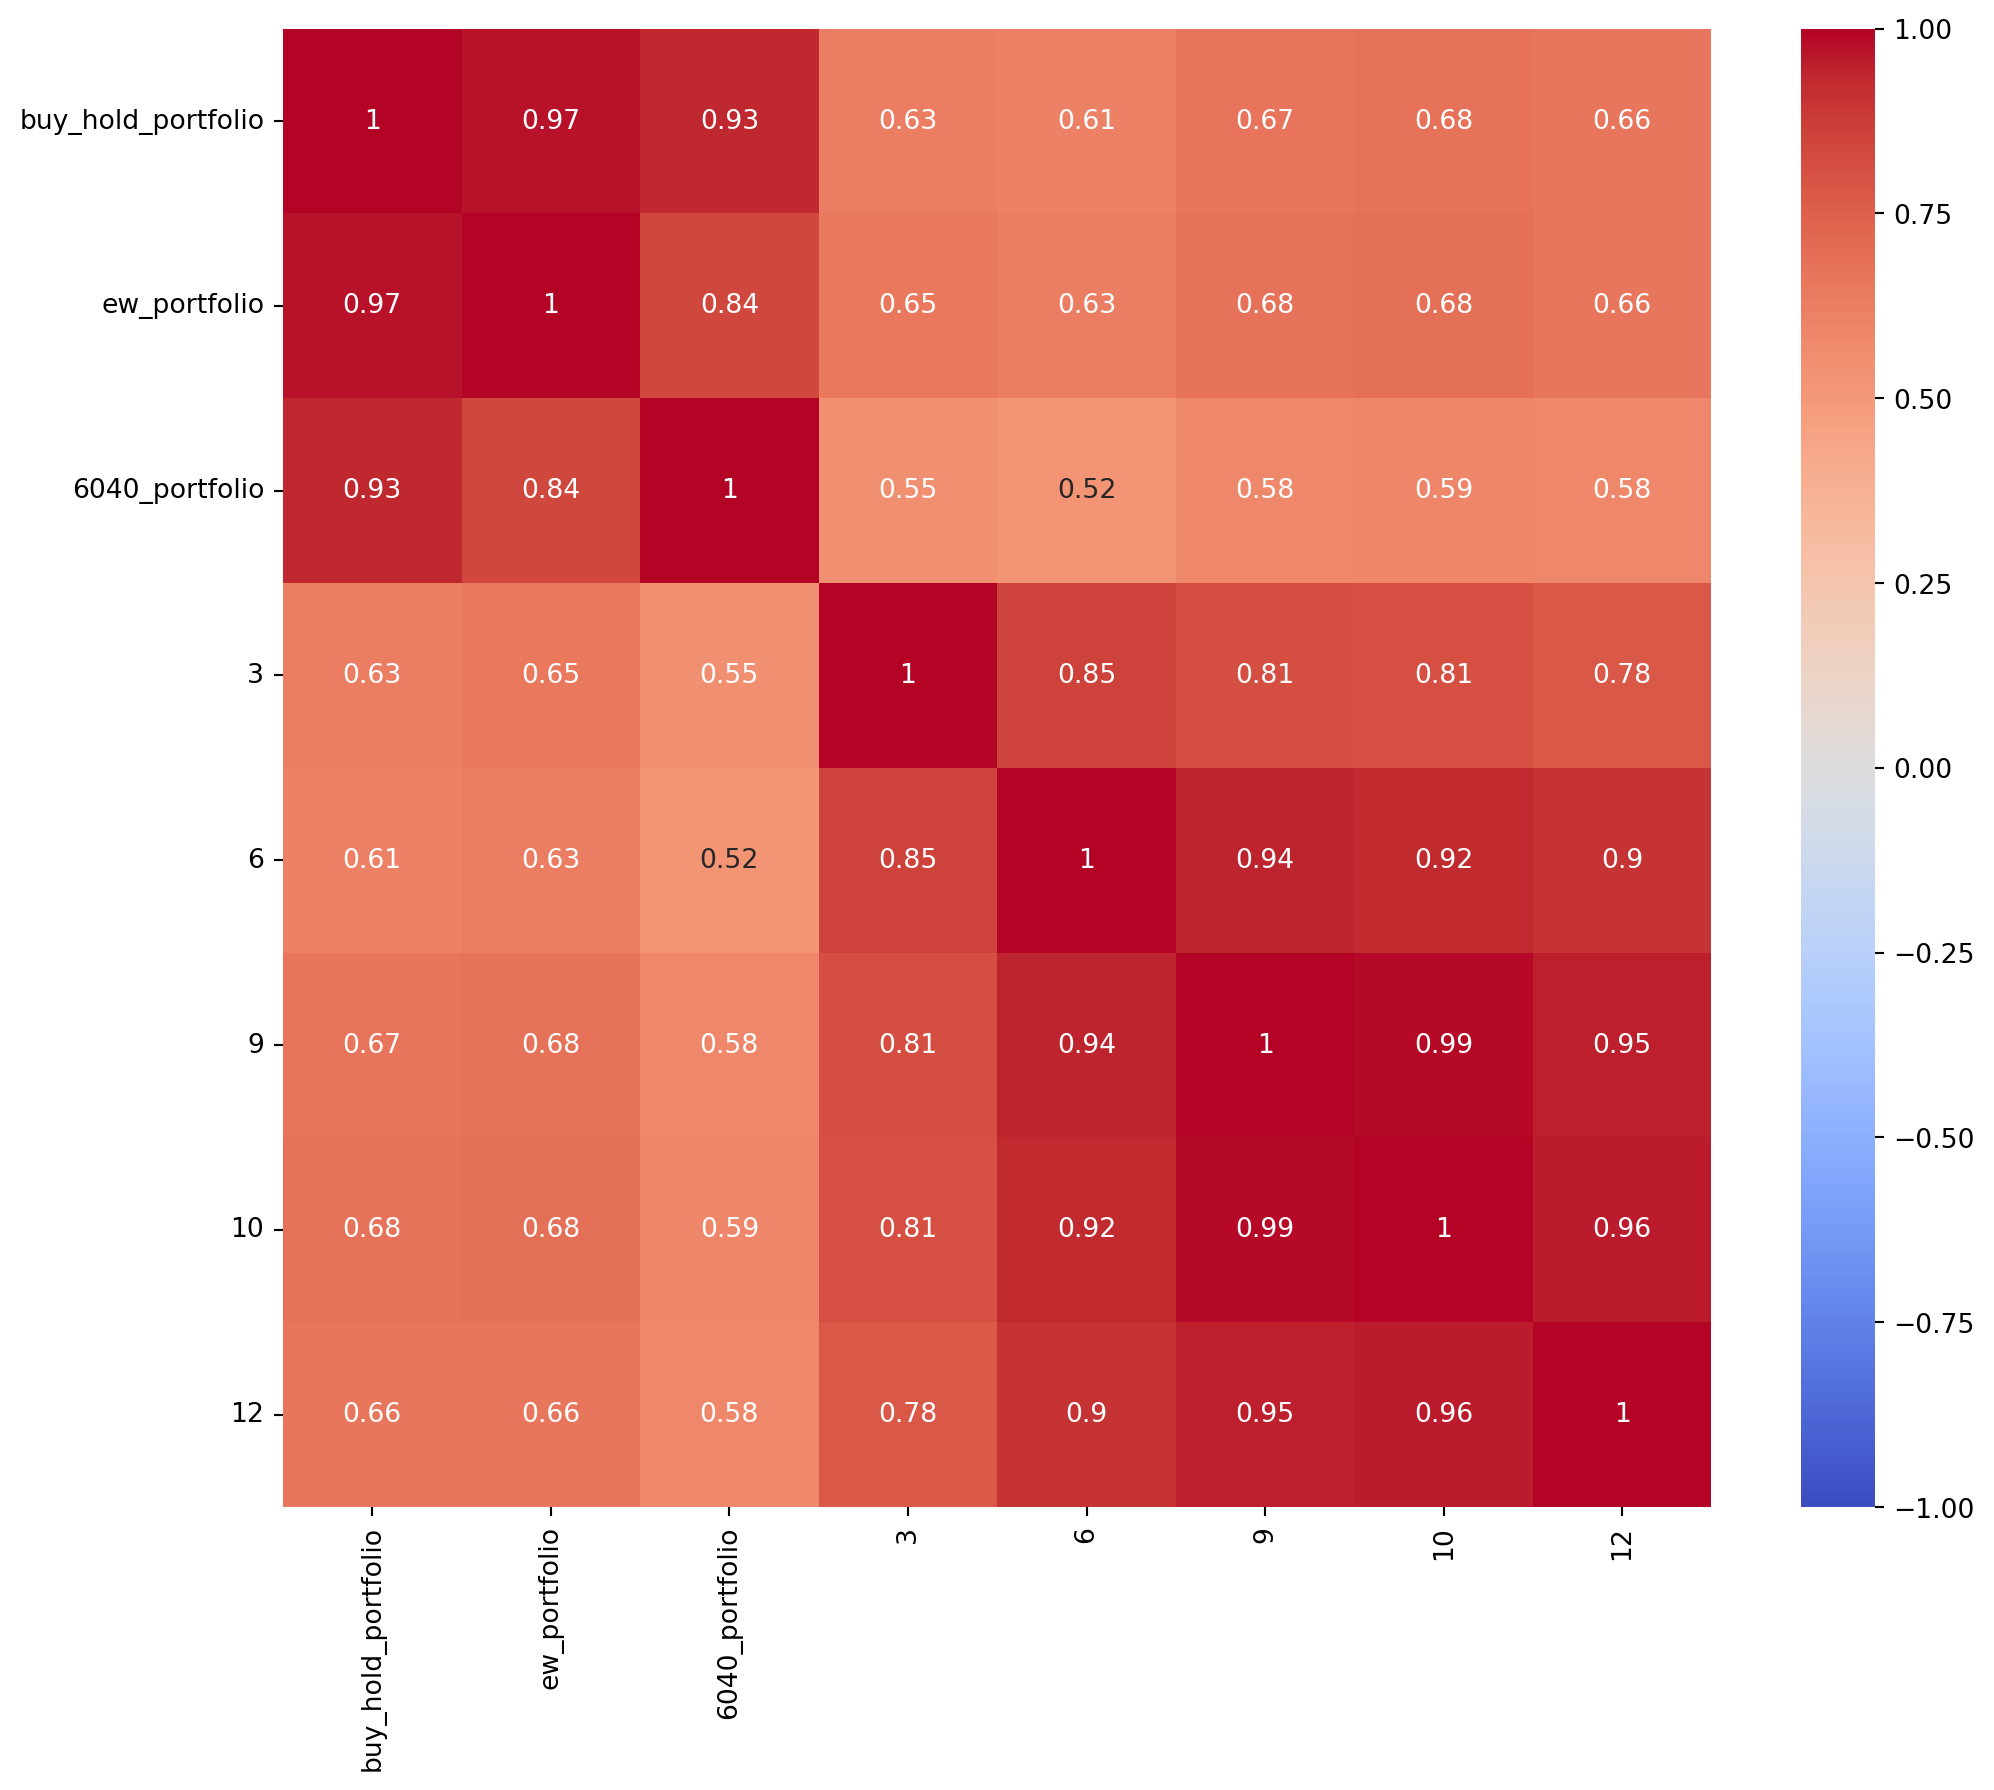

In [21]:
main.correlation_map(bt_lookbacks)

The timing strategies are pretty highly correlated with each other, especially from 9 to 12 months, where correlations are all above 0.95, so they’re basically capturing the same slow trend. The naive portfolios are also strongly correlated among themselves, which is what you’d expect. What’s interesting is that the timing strategies do manage to pull correlation down versus the naive portfolios, with most pairings landing around 0.52 to 0.68, so the timing overlay is clearly changing the ride in a meaningful way.

### 10 month SMA GTAA further analysis

Now I opt to further study the 10 month SMA strategy for two different reasons:
- it is the best proxy to the famous 200 day SMA timing overlay
- and it sits in the middle of both 9 and 12 SMAs, and since all these 3 were highly correlated it won't make a material difference anyway.

In [22]:
os_backtest = bt.Backtest(GTAAStrategy, screened_df, cash=100_000, commission=0.015)
os_result = os_backtest.run(sma_lookback=10)

#### Trades Analysis

In [23]:
os_result.trades

,symbol,open_date,close_date,bars_held,open_price,close_price,position_size,profit_loss,change_pct,trade_commission,cumulative_return,current_open_positions,why_exit
0,IEF,2013-01-01,2013-02-01,1,80.39,79.95,248,-109.94,-0.55,596.47,99293.59,4,Symbol below MA
1,GSG,2013-01-01,2013-03-01,2,33.19,32.35,602,-505.68,-2.53,591.83,98196.08,4,Symbol below MA
2,GSG,2013-04-01,2013-05-01,1,32.61,30.73,605,-1137.40,-5.77,574.81,96483.87,4,Symbol below MA
3,IEF,2013-05-01,2013-06-01,1,82.15,79.28,245,-703.97,-3.50,593.26,95186.64,4,Symbol below MA
4,IFGL,2013-01-01,2013-07-01,6,18.29,17.34,1093,-1037.58,-5.19,584.02,93565.04,3,Symbol below MA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,SPY,2023-12-01,2024-12-01,12,441.77,592.35,11,1656.41,34.09,170.63,99590.23,3,Rebalancing sell order
68,IEF,2024-08-01,2025-01-01,5,89.89,88.36,230,-351.71,-1.70,614.97,98623.54,4,Symbol below MA
69,IFGL,2024-09-01,2025-01-01,4,20.65,18.52,1009,-2150.12,-10.32,592.80,95880.62,3,Symbol below MA
70,SPY,2023-12-01,2025-04-01,17,441.77,551.13,34,3718.24,24.75,506.38,99092.47,4,Symbol below MA


In [24]:
os_result.open_positions

,symbol,open_date,last_date,bars_holding,open_price,last_price,position_size,profit_loss,change_pct,current_value
0,EFA,2025-02-01,2026-01-01,13,75.22,100.74,268,6839.18,33.93,26998.32
1,IEF,2025-02-01,2026-01-01,13,88.69,95.04,227,1441.21,7.16,21572.97
2,IFGL,2025-05-01,2026-01-01,10,20.46,24.06,973,3500.36,17.58,23407.15
3,SPY,2025-06-01,2026-01-01,9,581.10,690.09,34,3705.55,18.76,23462.90


At a first glance, it appears to exist several 1 month trades suggesting potential signal whipsaws.
All 5 tickers got traded in the sample period.

In [25]:
tools.metrics_trades(os_result.trades, full_metrics=True)

,Trades Analysis
Nr trades,72.00
Win Rate %,41.67
Profit Factor,2.05
Avg. Win %,21.27
Avg. Loss %,-4.13
Reward/Risk,5.15
Expectancy %,6.46
Avg. Bars Held,7.00
Commissions,38726.50
Max Bars Held,32.00


For the sample period, GTAA strategy completed 72 trades, averaging ~5.4 trades per year. No transaction costs were considered in this backtest. Longest trade lasted 32 months (that's almost 3 years), on average each trade lasted about 7 months.

Only 42% of the trades were winners with a 94% profit return for the best trade and -11.7% for the worst trade. On average winning trades are 5.2x bigger than losing trades.

As per the backtest expectancy, on each new trade it is expected to harvest ~6.4% profit.

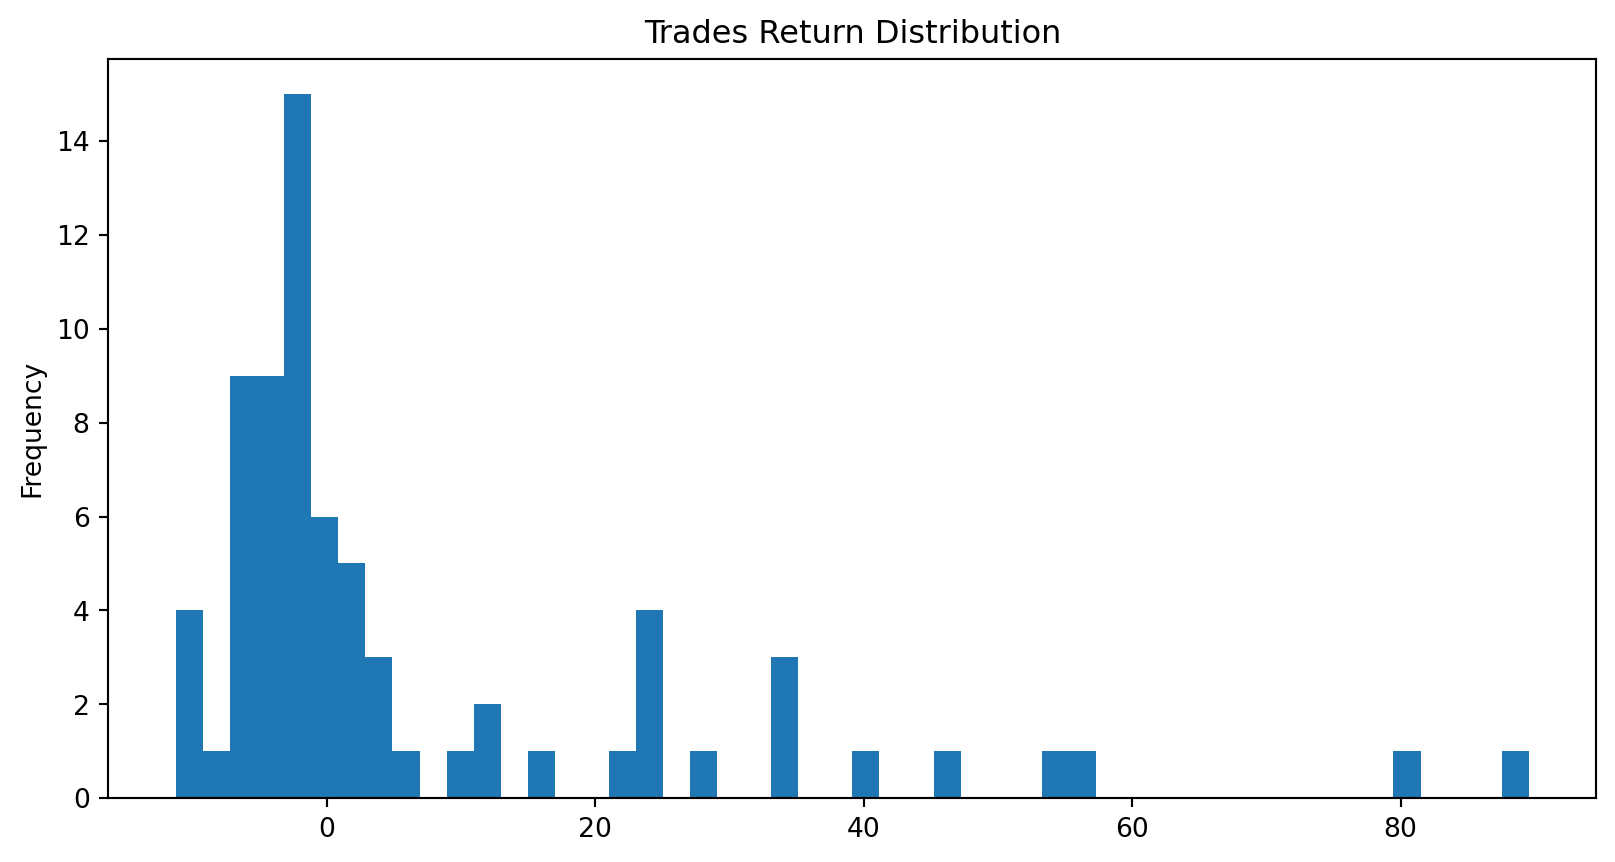

In [26]:
clipped_returns = main.cap_series(os_result.trades['change_pct'], percentile=0.005)
ax1 = clipped_returns.plot.hist(bins=50, title="Trades Return Distribution", figsize=(10, 5))

There is a high concentration of trades that returned near 0 returns on the downside and some trades that delivered exceptional returns on the upside, meaning that the timing overlay is working as intended, **cutting losses short and letting profits run**.

Avg. Bars Held: 7


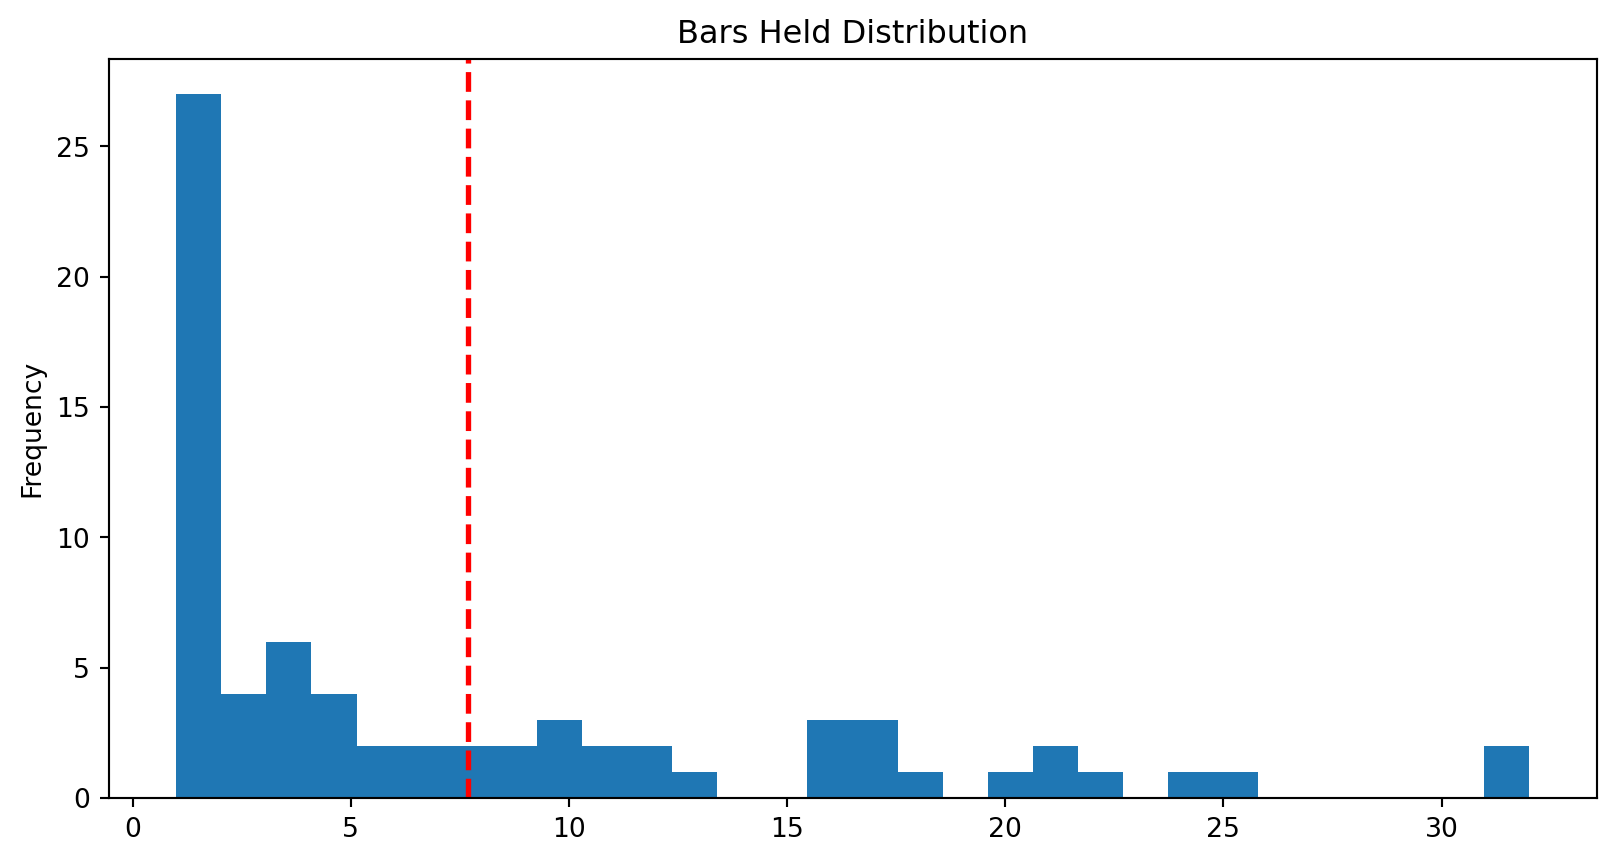

In [27]:
ax2 = os_result.trades['bars_held'].plot.hist(bins=30, title="Bars Held Distribution", figsize=(10, 5))
ax2.axvline(os_result.trades['bars_held'].mean(), color='red', linestyle='dashed', linewidth=2)
print("Avg. Bars Held:", int(os_result.trades['bars_held'].mean()))

Average trade lasted 7 months, about 27 trades only lasted 1 month eroding profits potential due to transactional costs.

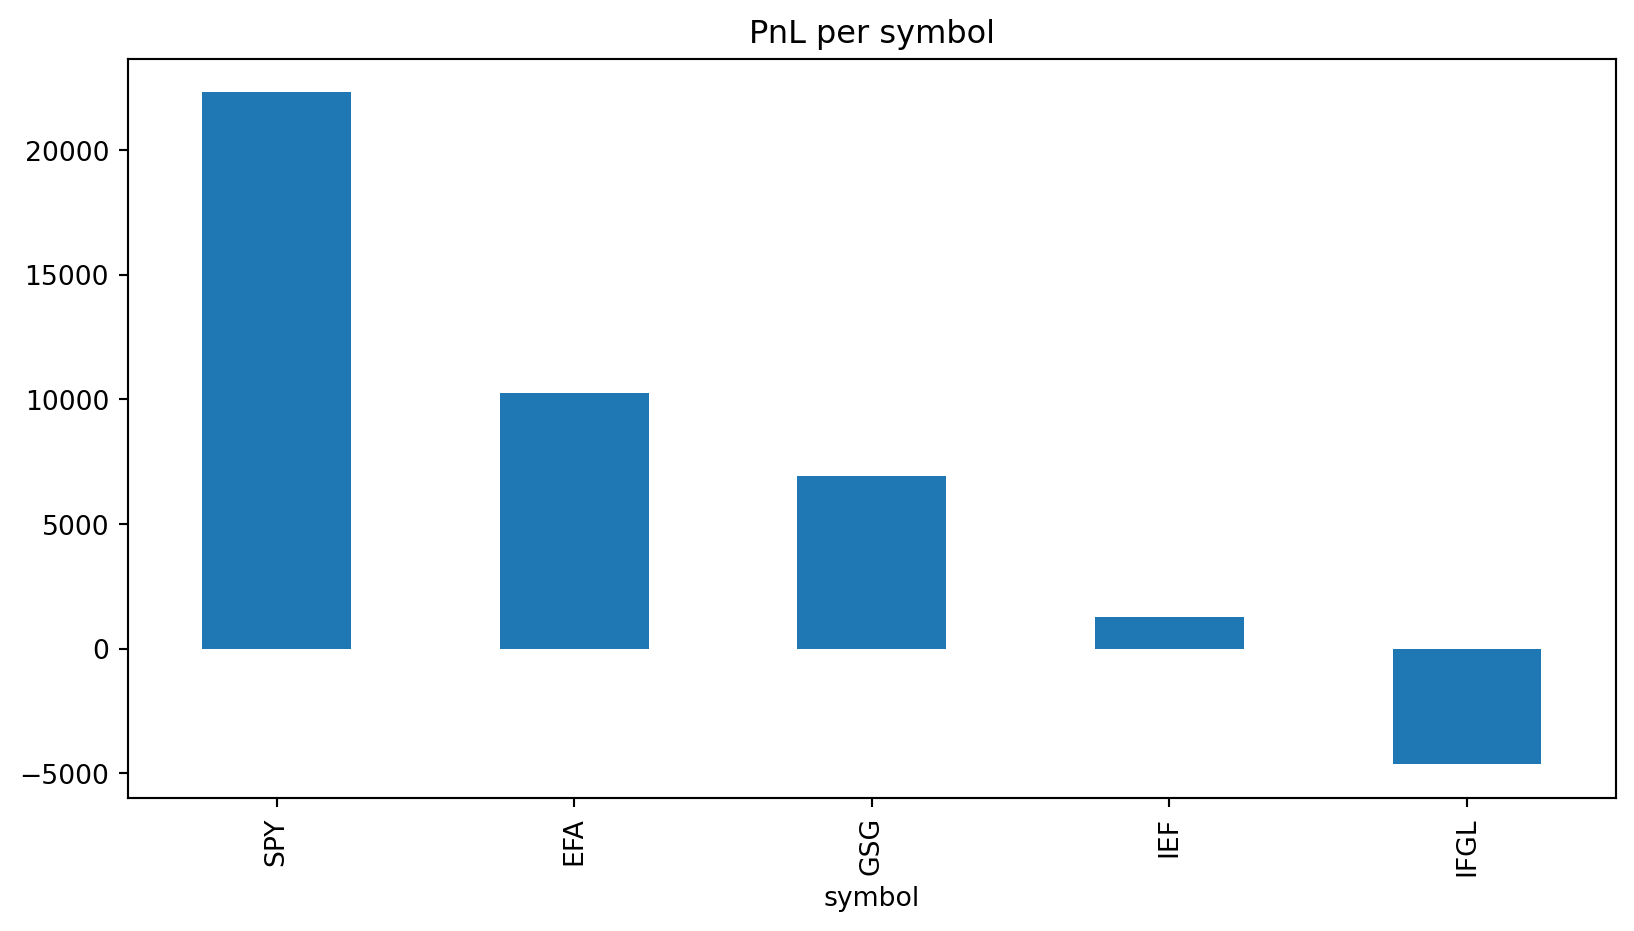

In [28]:
pnl_per_symbol = os_result.trades.groupby("symbol")["profit_loss"].sum().sort_values(ascending=False)
ax7 = pnl_per_symbol.plot.bar(title='PnL per symbol', figsize=(10,5))

SPY (S&P500) is the clear winner on the PnL subject, it has delievered over $25k profit, roughly double from EFA (MSCI EAFE) which is in second place with about $12.5k profit. GSG (GSCI Commodity-Indexed Trust) is right at the middle with roughly $10k profit, followed by IEF (7-10 Year Treasury Bond) with a modest PnL of $1k and lastly, the only one which incurred in losses IFGL (International Developed Real Estate) with roughly -$5k result.

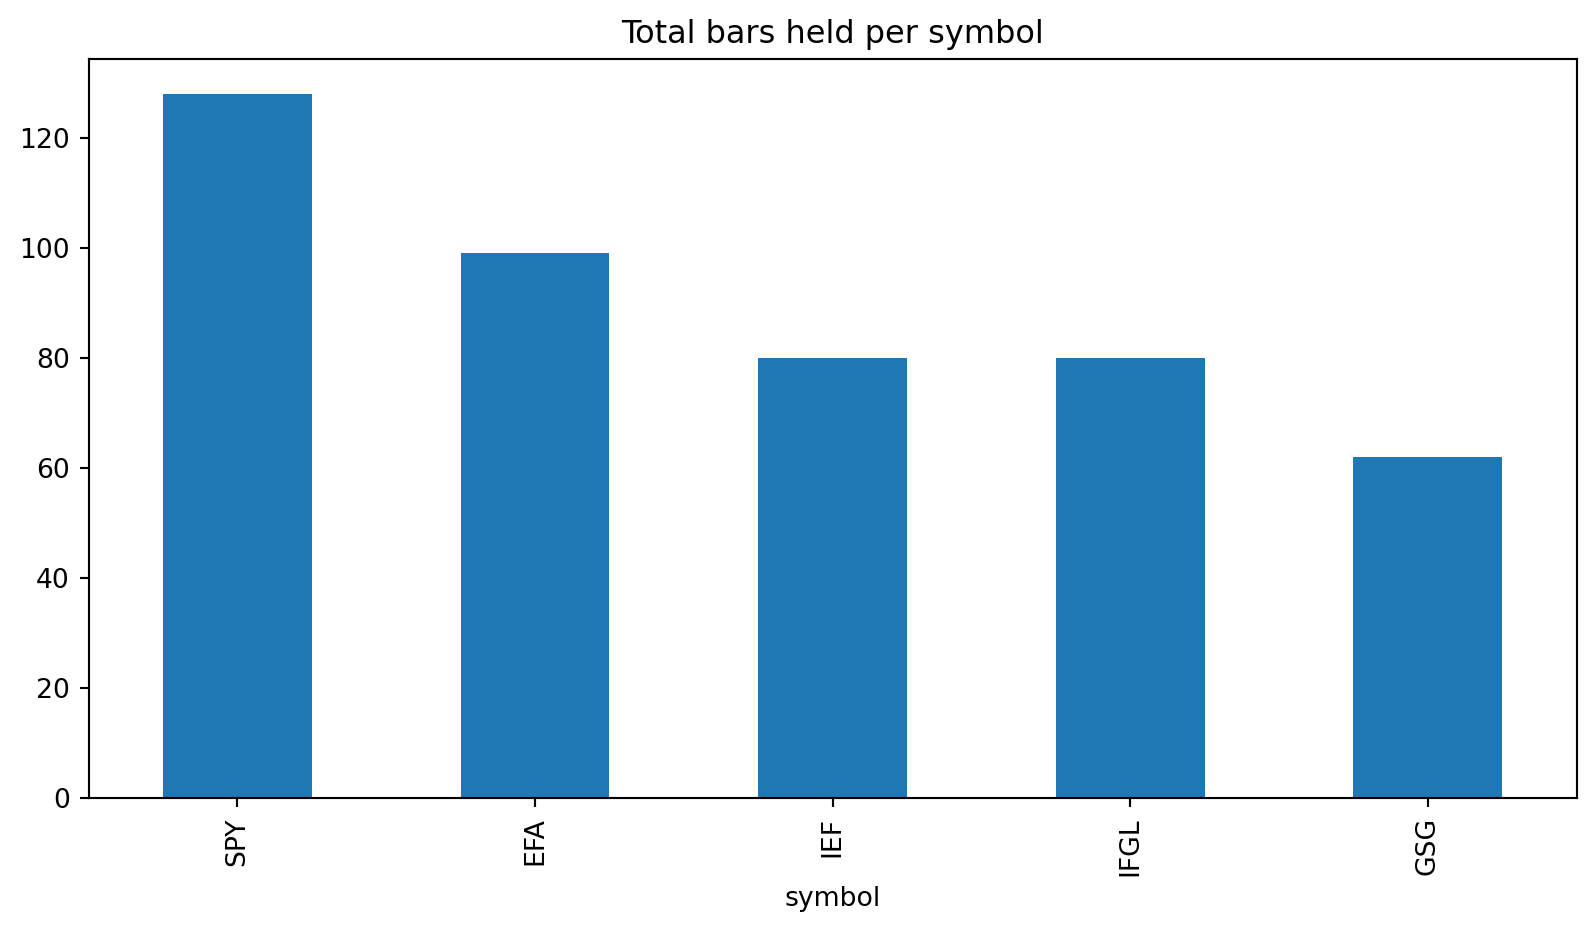

In [29]:
bars_per_symbol = (
    os_result.trades
    .loc[os_result.trades["why_exit"] != "Rebalancing sell order"]
    .groupby("symbol")["bars_held"]
    .sum()
).sort_values(ascending=False)

ax4 = bars_per_symbol.plot.bar(title='Total bars held per symbol', figsize=(10,5))

SPY had the highest exposure in the sample by a clear margin, followed by EFA, which shows the strategy stayed most consistently allocated to equities, especially U.S. stocks. At the other end, GSG had the lowest time in the portfolio, suggesting commodities were the least persistent sleeve during this OOS period.

In [30]:
total_bars_invested = bars_per_symbol.sum()
total_investable_bars = (len(screened_df)*5)

invested_capital = total_bars_invested/total_investable_bars
invested_capital

0.5719745222929936

In the end, capital was only insted ~57% of the time, the remaining was parked in cash, explaining both the performance drag and risk reduction.

In [31]:
import plotly.express as px

ax5 = px.scatter(os_result.trades, 
                 x='bars_held',
                 y='change_pct',
                 width=900,
                 height=500,
                 trendline="ols",
                 trendline_color_override="black",
                 title='Trade duration VS Trade Profit',
                 template='seaborn'
                 )

ax5.show()

The chart suggests a positive relationship between trade duration and profitability, with longer-held trades generally producing higher returns.

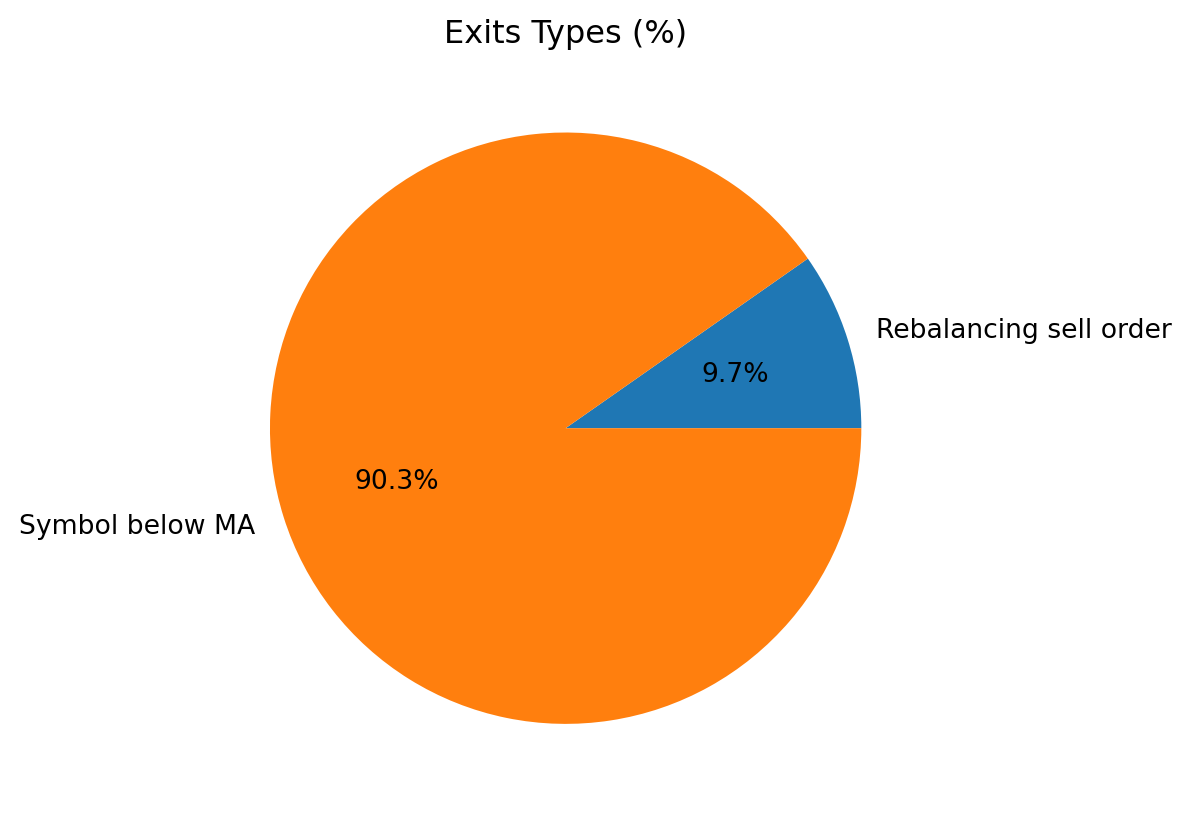

In [32]:
exit_types_df = ((os_result.trades.groupby(['why_exit']).size()/len(os_result.trades))*100).sort_values()

ax6 = exit_types_df.plot.pie(title='Exits Types (%)', figsize=(10,5), autopct='%1.1f%%')

Nearly 10% of sell trades are related to rebalancing due to overperformance, rebalacing threshold was 5%, so whenever any asset reached 25%+ portfolio weight got trimmed back to 20% allocation, aiming for an equal weighted portfolio.

##### Trades signals for SPY

In [33]:
spy_trades = os_result.trades[os_result.trades['symbol'] == 'SPY']
spy_trades

,symbol,open_date,close_date,bars_held,open_price,close_price,position_size,profit_loss,change_pct,trade_commission,cumulative_return,current_open_positions,why_exit
7,SPY,2013-02-01,2014-01-01,11,119.95,149.44,34,1002.83,24.59,137.39,92674.28,3,Rebalancing sell order
18,SPY,2013-02-01,2015-09-01,32,119.95,161.43,131,5433.84,34.58,552.90,90730.42,1,Symbol below MA
20,SPY,2015-11-01,2016-01-01,2,175.04,169.46,103,-574.37,-3.19,532.25,88890.66,1,Symbol below MA
27,SPY,2016-04-01,2017-12-01,20,173.61,231.85,21,1222.92,33.54,127.72,84529.22,3,Rebalancing sell order
34,SPY,2016-04-01,2018-11-01,32,173.61,242.18,81,5553.84,39.49,505.19,92081.15,1,Symbol below MA
35,SPY,2018-12-01,2019-01-01,1,249.92,220.62,73,-2139.17,-11.73,515.24,89426.75,2,Symbol below MA
37,SPY,2019-03-01,2019-06-01,3,251.52,248.01,71,-249.46,-1.40,532.00,87592.60,3,Symbol below MA
40,SPY,2019-07-01,2020-03-01,8,268.56,272.52,66,261.69,1.48,535.67,85750.25,2,Symbol below MA
47,SPY,2020-06-01,2021-12-01,18,279.10,433.96,13,2013.18,55.49,139.05,97194.53,3,Rebalancing sell order
50,SPY,2020-06-01,2022-03-01,22,279.10,410.39,51,6695.89,47.04,527.46,100748.94,2,Symbol below MA


In [34]:
tools.plot_trades_signals(screened_df['SPY'][['Close', 'SMA10']], spy_trades)

SPY got 4 rebalancing sell orders, which are visible in the graph, 2014 January; 2017 December; 2021 December and 2024 December, in order to maintain portfolio equal weightings.

##### Is it significantly different from 0?

In [35]:
main.compute_t_test(os_result.returns)

P-value: 0.5280446393950334 Fail to reject the null hypothesis (H₀). The strategys average return is not significantly different from zero.


##### Does it pass Monte Carlo Permutation?

This will shuffle the given equity curve returns in random order, all output equity curves start and end at the same place, only the path will vary, to obtain Confidence Intervals for Maximum Draw Down Figures.

In [36]:
#| code-fold: show

mcpyt = main.monte_carlo_permutation_yt(os_result.returns, nr_simulations=1000)
mcpyt.tail(3)

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
2025-11-01,1.19,1.11,1.16,1.13,1.11,1.08,1.11,1.11,1.15,1.16,...,1.11,1.08,1.13,1.13,1.13,1.11,1.12,1.13,1.12,1.12
2025-12-01,1.14,1.12,1.16,1.10,1.13,1.10,1.09,1.13,1.10,1.11,...,1.13,1.08,1.12,1.12,1.12,1.12,1.12,1.13,1.12,1.10
2026-01-01,1.12,1.12,1.12,1.12,1.12,1.12,1.12,1.12,1.12,1.12,...,1.12,1.12,1.12,1.12,1.12,1.12,1.12,1.12,1.12,1.12


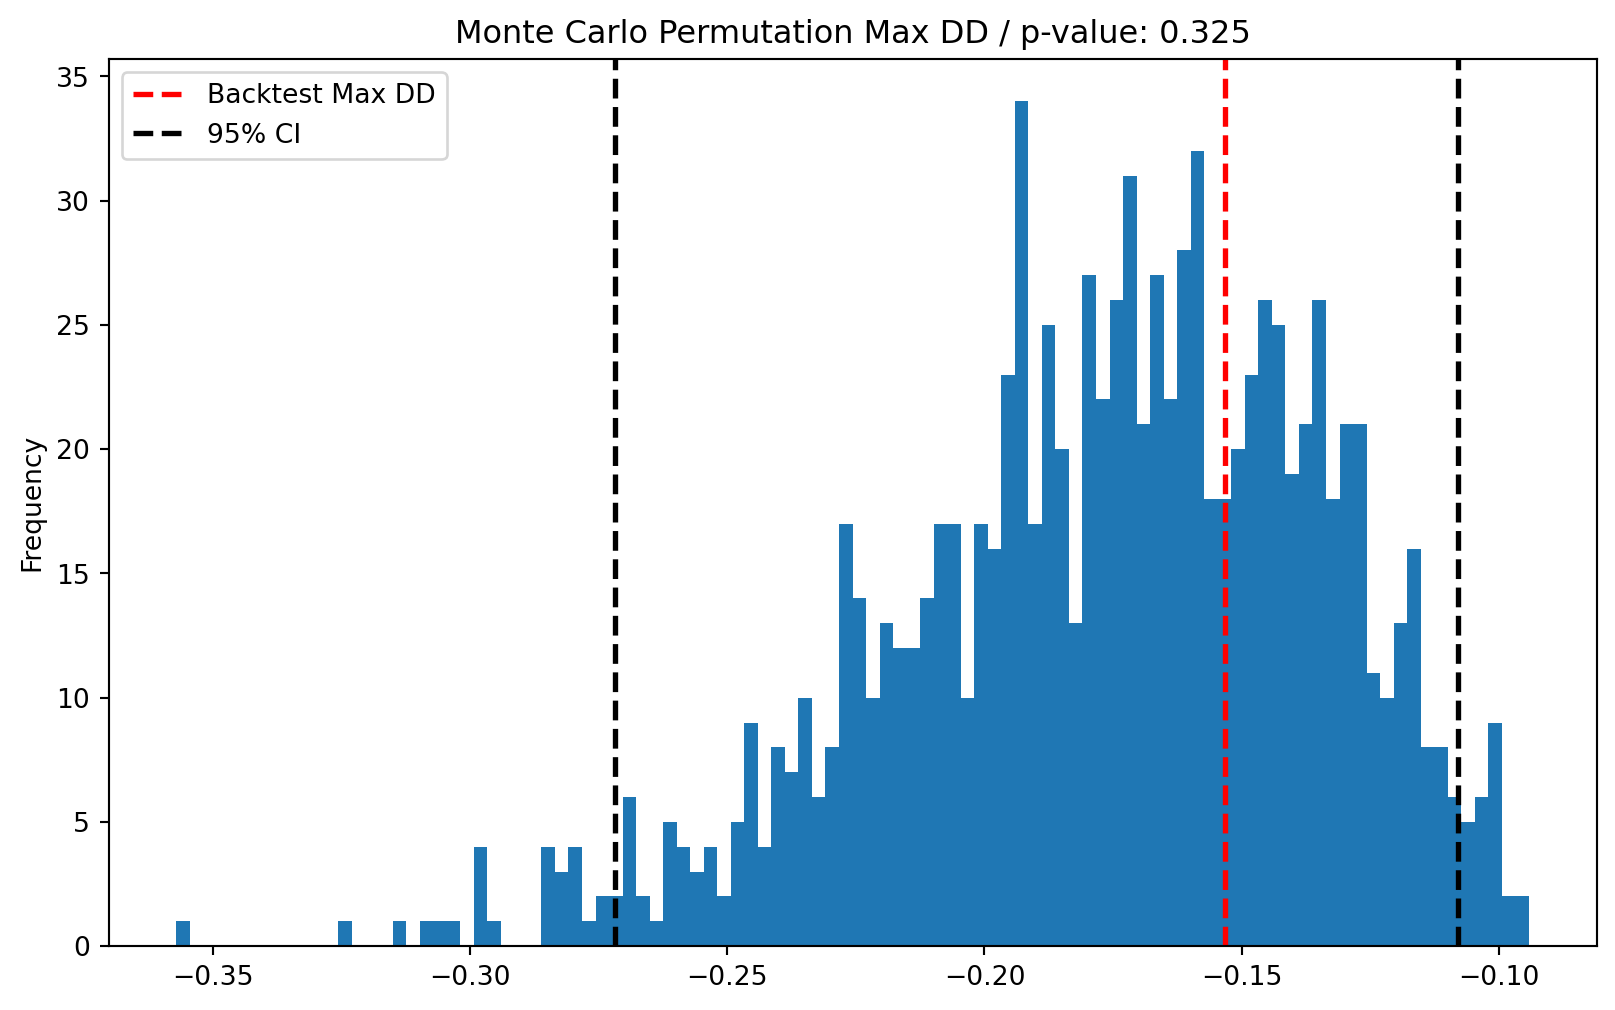

In [37]:
main.mcpyt_analysis(mcpyt, os_result.returns, ci=95)

Monte Carlo permutation analysis shows that the observed maximum drawdown of -15.15% is fairly typical relative to randomized return paths, with a p-value of 0.331. In other words, the backtest drawdown does not look unusually lucky or unusually harsh given the same return distribution, just a different ordering of returns. This suggests the reported drawdown is a plausible outcome for the strategy, while also reminding us that different return paths can still produce meaningfully deeper drawdowns.

## Does GTAA retain its risk-adjusted edge post-2013? - Final Thoughts

Overall, this OOS test paints a pretty clear picture, the naive portfolios, especially 60/40, delivered stronger absolute returns than the SMA tactical variants over this sample. The tactical models did improve risk control, with lower volatility and smaller drawdowns, but that downside protection came at the cost of meaningful upside drag in a market that largely rewarded staying invested. 

The outcome was driven mostly by the equity sleeves, with SPY and EFA carrying the bulk of the portfolio’s exposure through most of the sample. On the other side, GSG was the least persistent sleeve, so commodities had a much smaller role in the final result than stocks or bonds.

Within the timing group, the longer and slower lookbacks held up better than the shorter ones, suggesting that if a tactical overlay is used, a less reactive approach worked best here. **So the main takeaway is simple: in this OOS window, timing helped smooth the ride, but it did not beat the naive portfolios on absolute returns terms.**

Over this particular sample, GTAA did not manage to beat the 60/40 portfolio, either in raw returns or in risk-adjusted terms. Still, as the original paper itself points out, this type of strategy is better judged over full business cycles, so this OOS result is best seen as one useful piece of evidence rather than a definitive verdict.